In [1]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt


def temporal_average(cube1_path, cube2_path):
    # Load and process cube1
    cube1_img = nib.load(cube1_path)
    cube1_data = cube1_img.get_fdata()
    # Check if cube1 has 4 dimensions (includes time)
    if len(cube1_data.shape) == 4:
        cube1_data = np.mean(
            cube1_data[:, :, :, 30:75], axis=-1
        )  # Average over the time dimension (last dimension)
        # cube1_data = cube1_data[:,:,:,0] # take first temporal frame

    # Load and process cube2
    cube2_img = nib.load(cube2_path)
    cube2_data = cube2_img.get_fdata()
    # Check if cube2 has 4 dimensions (includes time)
    if len(cube2_data.shape) == 4:
        # Average over the time dimension (last dimension)
        cube2_data = np.mean(
            cube2_data[:, :, :, 30:75], axis=-1
        )  # Average over the time dimension (last dimension)
        # cube2_data = cube2_data[:,:,:,0] # take first temporal frame

    return cube1_data, cube2_data

In [2]:
data_path = "/Users/clairenastaskin/data/2025-03-07/task_audio_run-01_task-audio/"
cube1_path = os.path.join(data_path, "fUSi_data_after_processing_14mm_16mm.nii.gz")
cube2_path = os.path.join(data_path, "fUSi_data_after_processing_24mm_35mm.nii.gz")

averaged_over_time = False
if averaged_over_time:
    [cube1, cube2] = temporal_average(cube1_path, cube2_path)
else:
    cube1_img = nib.load(cube1_path)
    cube1 = cube1_img.get_fdata()

    cube2_img = nib.load(cube2_path)
    cube2 = cube2_img.get_fdata()

print(cube1.shape)
print(cube2.shape)

(187, 85, 89, 54)
(187, 85, 88, 54)


In [3]:
# Reshape cube1 to match cube2's dimensions using interpolation
from scipy.ndimage import zoom

# Calculate zoom factors for each dimension
total_dim = len(cube1.shape)  # Get number of dimensions instead of shape tuple
zoom_factors = [cube2.shape[i] / cube1.shape[i] for i in range(total_dim)]
# Apply interpolation to resize cube1
cube1 = zoom(cube1, zoom_factors, order=1)  # order=1 for linear interpolation

print("New cube1 shape:", cube1.shape)
print("Cube2 shape:", cube2.shape)

New cube1 shape: (187, 85, 88, 54)
Cube2 shape: (187, 85, 88, 54)


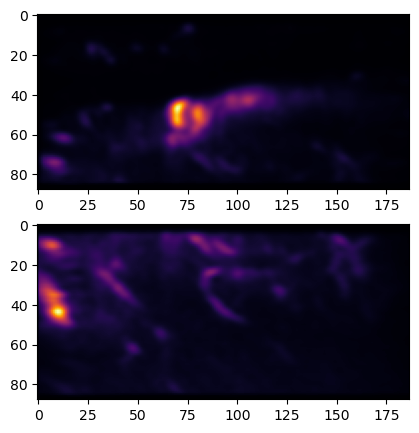

In [7]:
slicetolookat = 45

if len(cube1.shape) == 4:
    cube1tolookat = cube1[:, slicetolookat, :, 1]
    cube2tolookat = cube2[:, slicetolookat, :, 1]
else:
    cube1tolookat = cube1[:, slicetolookat, :]
    cube2tolookat = cube2[:, slicetolookat, :]


plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.imshow(cube1tolookat.T, cmap="inferno")
plt.subplot(2, 1, 2)
plt.imshow(cube2tolookat.T, cmap="inferno")
plt.show()

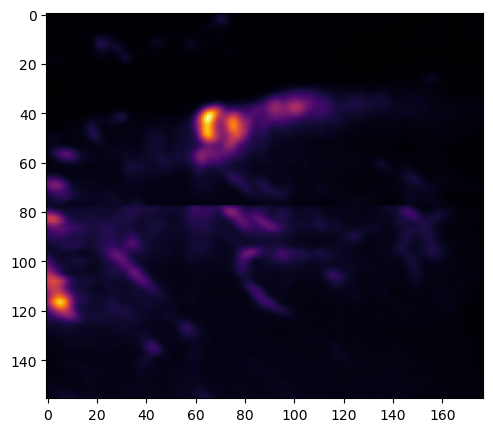

In [10]:
slicetolookat = 45

if len(cube1.shape) == 4:
    concatenated_cube = np.concatenate(
        (cube1[5:182, :, 5:83, :], 1 * cube2[5:182, :, 5:83, :]), axis=2
    )
    concatenated_cube_tolookat = concatenated_cube[:, slicetolookat, :, 1]
else:
    concatenated_cube = np.concatenate(
        (cube1[5:182, :, 5:83], 1 * cube2[5:182, :, 5:83]), axis=2
    )
    concatenated_cube_tolookat = concatenated_cube[:, slicetolookat, :]

plt.figure(figsize=(10, 5))
# Select a specific time point (e.g. first time point) to visualize the 2D slice
plt.imshow(concatenated_cube_tolookat.T, cmap="inferno")
plt.show()
nib.save(
    nib.Nifti1Image(concatenated_cube, np.eye(4)),
    os.path.join(data_path, "concatenated_cube.nii.gz"),
)

In [6]:
############################################
#     Display and save propagation movie   #
############################################

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
cax = ax.imshow(cube1[:, 44, :, 0].T, cmap="inferno", extent=[0, 30, 35, 15])
ax.set_title("0")

# Set axis labels
ax.set_xlabel("Y (mm)")
ax.set_ylabel("X (mm)")


def update(frame):
    cax.set_data(cube1[:, 44, :, frame].T)
    ax.set_title(f"Frame # {frame}")


# Create a list of frames to plot every frame
frames_to_plot = range(0, cube1.shape[3], 1)
ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

# Display the animation in the Jupyter Notebook
display(HTML(ani.to_jshtml()))

# Close the figure to prevent it from displaying statically
plt.close(fig)

# Save the animation as an MP4 file
ani.save(experiment_path / "cortical_propagation.mp4", writer="ffmpeg")

NameError: name 'experiment_path' is not defined